# 📉 Topic 26: Locally Weighted Regression

**Summary:** Practical implementation and evaluation of locally weighted regression.

---

## 📝 Core Concepts & Explanations

### Bandwidth Parameter ($\tau$)
- $\tau$ too large: High bias (local weights become flat, converges to global linear regression).
- $\tau$ too small: High variance (fits local noise).

## 💻 Code Demonstration
Run the cells below to see the concepts in action:

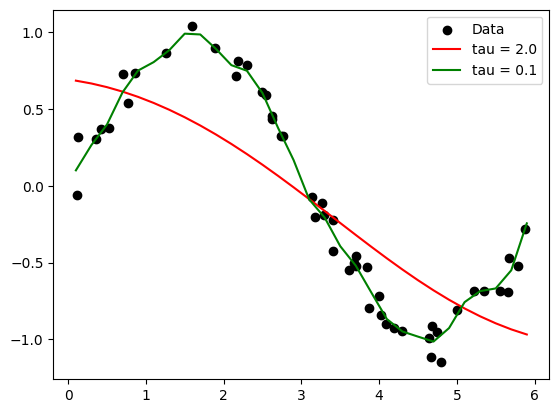

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Generate noisy 1D sine wave
np.random.seed(0)
X = np.sort(np.random.rand(50) * 6)
y = np.sin(X) + np.random.randn(50) * 0.1

def lwr_predict(x_query, X, y, tau):
    weights = np.exp(-((X - x_query)**2) / (2 * tau**2))
    W = np.diag(weights)
    X_b = np.c_[np.ones(len(X)), X]
    query_b = np.array([1, x_query])
    theta = np.linalg.inv(X_b.T.dot(W).dot(X_b)).dot(X_b.T).dot(W).dot(y)
    return query_b.dot(theta)

queries = np.linspace(0.1, 5.9, 30)
preds_large_tau = [lwr_predict(q, X, y, tau=2.0) for q in queries]
preds_small_tau = [lwr_predict(q, X, y, tau=0.1) for q in queries]

plt.scatter(X, y, color='black', label='Data')
plt.plot(queries, preds_large_tau, 'r-', label='tau = 2.0')
plt.plot(queries, preds_small_tau, 'g-', label='tau = 0.1')
plt.legend()
plt.show()


### Exercises
1. Explain the effect of setting $\tau=0.1$ compared to $\tau=2.0$ based on the plot.

In [2]:
print('tau=0.1 captures non-linear curvature cleanly. tau=2.0 underfits because the weights are too flat.')


tau=0.1 captures non-linear curvature cleanly. tau=2.0 underfits because the weights are too flat.
